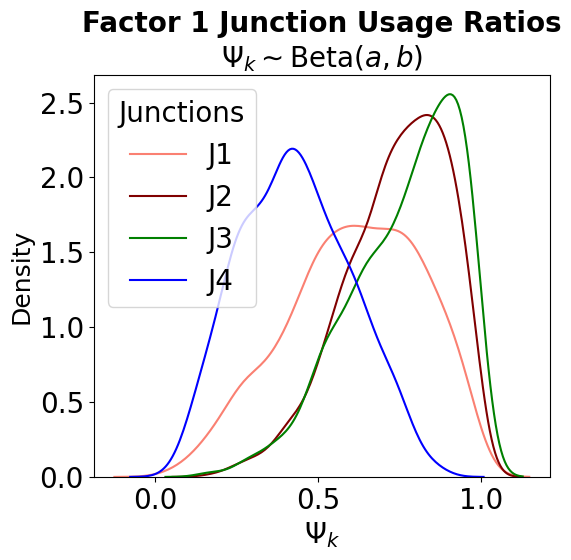

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta
from matplotlib.lines import Line2D

# Set seed for reproducibility
np.random.seed(42)

plt.rcParams.update({
    'font.size': 20,      # Global font size
    'axes.titlesize': 24, # Font size of plot titles
    'axes.labelsize': 20, # Font size of x and y labels
    'xtick.labelsize': 20,# Font size of x tick labels
    'ytick.labelsize': 20,# Font size of y tick labels
    'legend.fontsize': 20,# Font size of legend
    'figure.figsize': (6, 6) # Default figure size
})

# Parameters
K = 2   # Number of factors
J = 4   # Number of junctions
N = 20  # Number of cells

# Define parameters for one factor and four junctions
J = 4   # Number of junctions

# Color mapping for the four junctions
junction_colors = {
    'J1': 'salmon', 
    'J2': 'maroon', 
    'J3': 'green',  # Adjusted to a clearer green
    'J4': 'blue'
}

# Generate a_j and b_j for the Beta distribution for each factor and junction
a_j = np.random.uniform(1, 5, J)
b_j = np.random.uniform(1, 5, J)

# Simulate PSI values for each junction
psi_values = {f'J{j+1}': beta.rvs(a_j[j], b_j[j], size=1000) for j in range(J)}

# Create a DataFrame for plotting
psi_data = pd.DataFrame({key: value for key, value in psi_values.items()})

# Plotting each junction with KDE (Kernel Density Estimate) in specified colors
plt.figure(figsize=(6, 6))
for junction, color in junction_colors.items():
    sns.kdeplot(psi_data[junction], color=color, fill=False, label=junction)

# Set labels and title
plt.title(r'Factor 1 Junction Usage Ratios' '\n' r'$\Psi_k \sim \mathrm{Beta}(a, b)$', fontweight='bold', fontsize=20)
plt.xlabel(r'$\Psi_k$', fontsize=20)
plt.ylabel('Density', fontsize=18)
plt.legend(title='Junctions')
plt.tight_layout()

# Save the figure in PDF format
plt.savefig("factor1_junction_usage_ratios.pdf", format="pdf")

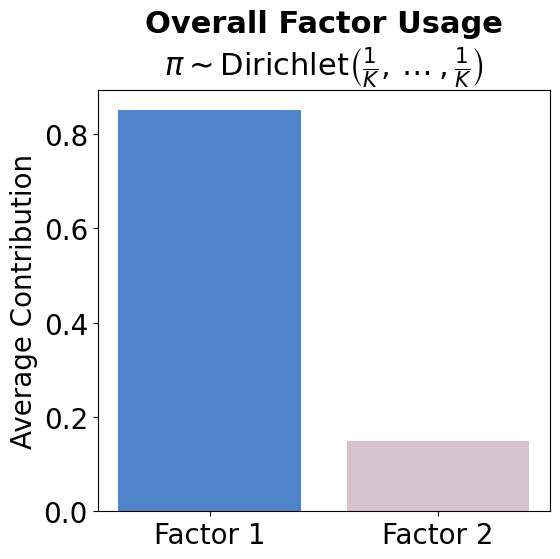

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define parameters
K = 2  # Number of factors

# Updated colors for factors
colors = ['#4f83cc', '#d6c2cc']  # Factor 1: more blue, Factor 2: pink pastel

plt.rcParams.update({
    'font.size': 20,      # Global font size
    'axes.titlesize': 24, # Font size of plot titles
    'axes.labelsize': 20, # Font size of x and y labels
    'xtick.labelsize': 20,# Font size of x tick labels
    'ytick.labelsize': 20,# Font size of y tick labels
    'legend.fontsize': 20,# Font size of legend
    'figure.figsize': (6, 6) # Default figure size
})

# Generate pi ~ Dirichlet([1/K, ..., 1/K])
alpha_pi = np.ones(K)
pi = np.random.dirichlet(alpha_pi, size=1).flatten()
pi_df = pd.DataFrame({
    'Factor': [f'Factor {i+1}' for i in range(K)],
    'Contribution': pi
})

# Plot
plt.figure(figsize=(6, 6))
plt.bar(pi_df['Factor'], pi_df['Contribution'], color=colors)
plt.title(r'Overall Factor Usage' '\n' r'$\pi \sim \mathrm{Dirichlet}\left(\frac{1}{K}, \dots, \frac{1}{K}\right)$',
          fontweight='bold', fontsize=22)
plt.xlabel('')
plt.ylabel('Average Contribution')
plt.tight_layout()

# Save as PDF
plt.savefig("fig1_overall_factor_usage.pdf", format="pdf")

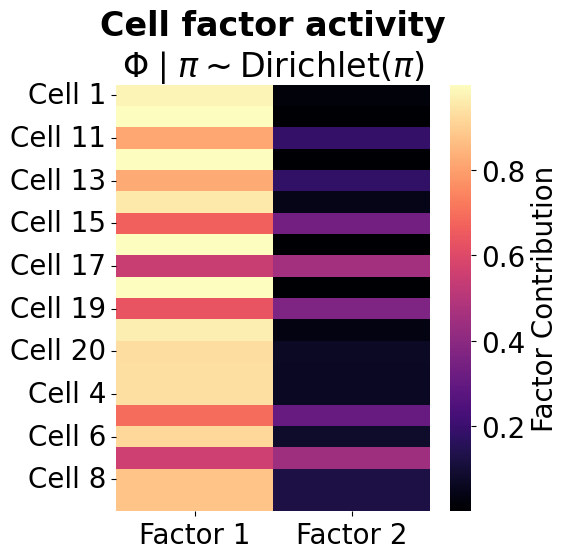

In [18]:
# Generate phi_n | pi ~ Dirichlet(pi)
phi = np.random.dirichlet(pi * K, size=N)
phi_df = pd.DataFrame(phi, columns=[f'Factor {i+1}' for i in range(K)])
phi_df['Cell'] = [f'Cell {i+1}' for i in range(N)]
phi_melt = phi_df.melt(id_vars='Cell', var_name='Factor', value_name='Contribution')

# Plot phi as heatmap
phi_pivot = phi_melt.pivot(index='Cell', columns='Factor', values='Contribution')
plt.figure(figsize=(6, 6))
ax = sns.heatmap(phi_pivot, cmap='magma', cbar_kws={'label': 'Factor Contribution'})
ax.set_title(r'Cell factor activity' '\n' r'$\Phi \mid \pi \sim \mathrm{Dirichlet}(\pi)$', 
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels())
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('Factor Contribution')
plt.tight_layout()
plt.savefig("fig1_cell_factor_activity.pdf", format="pdf")

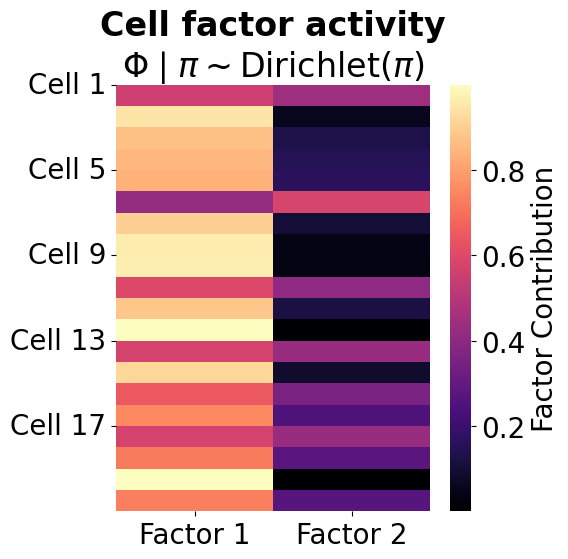

In [5]:
# Generate phi_n | pi ~ Dirichlet(pi)
phi = np.random.dirichlet(pi * K, size=N)
phi_df = pd.DataFrame(phi, columns=[f'Factor {i+1}' for i in range(K)])
phi_df['Cell'] = [f'Cell {i+1}' for i in range(N)]
phi_melt = phi_df.melt(id_vars='Cell', var_name='Factor', value_name='Contribution')

# Plot phi as heatmap
phi_pivot = phi_melt.pivot(index='Cell', columns='Factor', values='Contribution')
plt.figure(figsize=(6, 6))
ax = sns.heatmap(phi_pivot, cmap='magma', cbar_kws={'label': 'Factor Contribution'})
ax.set_title(r'Cell factor activity' '\n' r'$\Phi \mid \pi \sim \mathrm{Dirichlet}(\pi)$', 
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

# Set y-ticks to show fewer cells, e.g., every 10th cell
n_cells_to_show = 5
ax.set_yticks(np.arange(0, N, N // n_cells_to_show))  # Set fewer y-ticks
ax.set_yticklabels([f'Cell {i+1}' for i in range(0, N, N // n_cells_to_show)], rotation=0)

# Customize x-tick labels
ax.set_xticklabels(ax.get_xticklabels())
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('Factor Contribution')

plt.tight_layout()
plt.show()


In [6]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of junctions and cells
n_cells = 100
n_junctions = 5  # Fewer junctions for clarity

# Global prior: Sample a and b from Gamma(1,1) and use them for all junctions
a_global = np.random.gamma(shape=1, scale=1)
b_global = np.random.gamma(shape=1, scale=1)

# Sample psi values for all junctions using global a and b
psi_global = np.random.beta(a_global, b_global, size=(n_cells, n_junctions))

# Junction-specific prior: Sample a_j and b_j from Gamma(1,1) for each junction
a_junction_specific = np.random.gamma(shape=1, scale=1, size=n_junctions)
b_junction_specific = np.random.gamma(shape=1, scale=1, size=n_junctions)

# Sample psi values for each junction using its own a_j and b_j
psi_junction_specific = np.array([np.random.beta(a_j, b_j, size=n_cells) 
                                  for a_j, b_j in zip(a_junction_specific, b_junction_specific)]).T

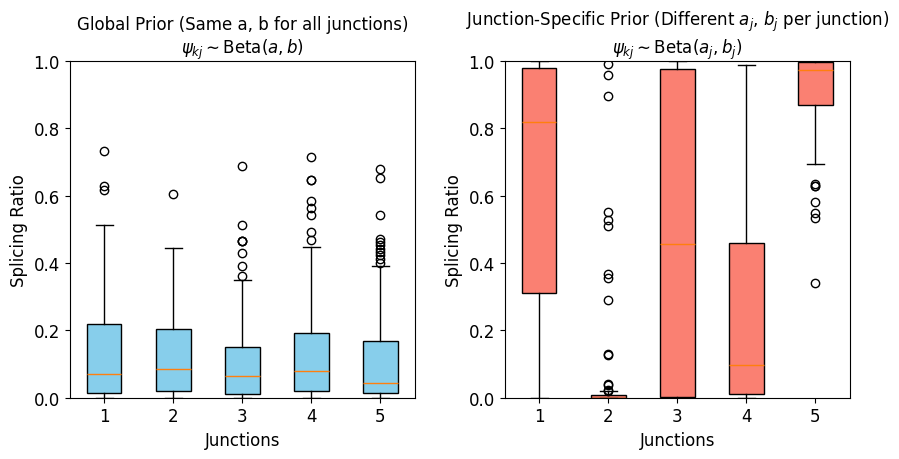

In [7]:
# Create a figure with two subplots for comparison with updated subtitles and fixed LaTeX
plt.figure(figsize=(9, 5))

# Plot for the global prior (using one a, b pair for all junctions)
plt.subplot(1, 2, 1)
plt.boxplot(psi_global, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title(r"Global Prior (Same a, b for all junctions)" "\n" r"$\psi_{kj} \sim \mathrm{Beta}(a, b)$", fontsize=12)

plt.xlabel("Junctions", fontsize=12)
plt.ylabel("Splicing Ratio", fontsize=12)
plt.ylim(0, 1)

# Adjust the tick parameters for smaller font size on x and y axes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Plot for the junction-specific prior (different a_j, b_j for each junction)
plt.subplot(1, 2, 2)
plt.boxplot(psi_junction_specific, patch_artist=True, boxprops=dict(facecolor='salmon'))
plt.title(r"Junction-Specific Prior (Different $a_j$, $b_j$ per junction)" "\n"
          r"$\psi_{kj} \sim \mathrm{Beta}(a_j, b_j)$", fontsize=12)
plt.xlabel("Junctions", fontsize=12)
plt.ylabel("Splicing Ratio", fontsize=12)
plt.ylim(0, 1)

# Adjust the tick parameters for smaller font size on x and y axes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the plots
plt.tight_layout()

plt.savefig('visualization_junc_shape_prior.pdf', bbox_inches='tight', format='pdf')

plt.show()